In [1]:
# Hybrid Identity Anomaly Detection – LANL Authentication Logs

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Paths
DATA_RAW = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

print("✅ All imports loaded successfully.")

✅ All imports loaded successfully.


In [3]:
print("⏳ Loading auth.txt.gz — sampling 500,000 rows to fit in memory...")

# Full LANL dataset is ~1.6 billion rows — sample a representative slice
SAMPLE_ROWS = 500_000

df = pd.read_csv(
    DATA_RAW / 'auth.txt.gz',
    compression='gzip',
    header=None,
    names=['time', 'src_user', 'dst_user', 'src_pc', 'dst_pc',
           'auth_type', 'logon_type', 'orientation', 'success'],
    sep=',',
    nrows=SAMPLE_ROWS,
    dtype={
        'time': 'int32',
        'src_user': 'category',
        'dst_user': 'category',
        'src_pc': 'category',
        'dst_pc': 'category',
        'auth_type': 'category',
        'logon_type': 'category',
        'orientation': 'category',
        'success': 'category',
    }
)

print(f"✅ Loaded {len(df):,} events (sample of full dataset).")
print(f"   Columns    : {df.columns.tolist()}")
print(f"   Time range : {df['time'].min():,} – {df['time'].max():,} seconds")
print(f"   Memory used: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

⏳ Loading auth.txt.gz — sampling 500,000 rows to fit in memory...
✅ Loaded 500,000 events (sample of full dataset).
   Columns    : ['time', 'src_user', 'dst_user', 'src_pc', 'dst_pc', 'auth_type', 'logon_type', 'orientation', 'success']
   Time range : 1 – 5,118 seconds
   Memory used: 9.2 MB


,time,src_user,dst_user,src_pc,dst_pc,auth_type,logon_type,orientation,success
0,1,ANONYMOUS LOGON@C586,ANONYMOUS LOGON@C586,C1250,C586,NTLM,Network,LogOn,Success
1,1,ANONYMOUS LOGON@C586,ANONYMOUS LOGON@C586,C586,C586,?,Network,LogOff,Success
2,1,C101$@DOM1,C101$@DOM1,C988,C988,?,Network,LogOff,Success
3,1,C1020$@DOM1,SYSTEM@C1020,C1020,C1020,Negotiate,Service,LogOn,Success
4,1,C1021$@DOM1,C1021$@DOM1,C1021,C625,Kerberos,Network,LogOn,Success


In [4]:
print("⏳ Engineering features...")

# LANL time is integer seconds from day 1 — derive hour/day directly
df['hour']        = (df['time'] % 86400) // 3600
df['day_of_week'] = (df['time'] // 86400) % 7
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)
print("   ✓ Time features: hour, day_of_week, is_weekend")

# Logins per user per hour (behavioural baseline)
user_hourly = df.groupby(['src_user', 'hour']).size().reset_index(name='hourly_count')
df = df.merge(user_hourly, on=['src_user', 'hour'], how='left')
print("   ✓ Hourly login counts per user")

# Unique source PCs per user (lateral movement indicator)
user_pc_diversity = df.groupby('src_user')['src_pc'].nunique().reset_index(name='unique_pcs')
df = df.merge(user_pc_diversity, on='src_user', how='left')
print("   ✓ Unique PC diversity per user")

# Encode categorical columns
df['logon_type_code']  = pd.factorize(df['logon_type'])[0]
df['auth_type_code']   = pd.factorize(df['auth_type'])[0]
df['orientation_code'] = pd.factorize(df['orientation'])[0]
df['success_code']     = pd.factorize(df['success'])[0]
print("   ✓ Categorical columns encoded")

feature_cols = [
    'hour', 'day_of_week', 'is_weekend',
    'hourly_count', 'unique_pcs',
    'logon_type_code', 'auth_type_code', 'orientation_code', 'success_code'
]
X = df[feature_cols].fillna(0)

print(f"\n✅ Feature matrix ready: {X.shape[0]:,} rows × {X.shape[1]} features")
X.head()

⏳ Engineering features...
   ✓ Time features: hour, day_of_week, is_weekend
   ✓ Hourly login counts per user
   ✓ Unique PC diversity per user
   ✓ Categorical columns encoded

✅ Feature matrix ready: 500,000 rows × 9 features


,hour,day_of_week,is_weekend,hourly_count,unique_pcs,logon_type_code,auth_type_code,orientation_code,success_code
0,0,0,0,6242,578,0,0,0,0
1,0,0,0,6242,578,0,1,1,0
2,0,0,0,1103,13,0,1,1,0
3,0,0,0,58,7,1,2,0,0
4,0,0,0,17,6,0,3,0,0


In [5]:
print("⏳ Scaling features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("   ✓ Features standardised")

print("⏳ Training Isolation Forest (100 trees) — may take a moment on large data...")
model = IsolationForest(
    contamination=0.01,
    random_state=SEED,
    n_estimators=100,
    verbose=0
)
model.fit(X_scaled)
print("   ✓ Model trained")

print("⏳ Scoring all events...")
df['anomaly'] = model.predict(X_scaled)
anomalies = df[df['anomaly'] == -1]

print(f"\n✅ Done.")
print(f"   Total events  : {len(df):,}")
print(f"   Anomalies     : {len(anomalies):,} ({len(anomalies)/len(df)*100:.2f}%)")
print(f"   Normal events : {len(df) - len(anomalies):,}")

⏳ Scaling features...
   ✓ Features standardised
⏳ Training Isolation Forest (100 trees) — may take a moment on large data...
   ✓ Model trained
⏳ Scoring all events...

✅ Done.
   Total events  : 500,000
   Anomalies     : 2,846 (0.57%)
   Normal events : 497,154


In [6]:
print("⏳ Analysing anomalous users...")
top_anomalous_users = anomalies['src_user'].value_counts().head(10)
print("\nTop 10 users with most anomalous events:")
print(top_anomalous_users.to_string())

# Check against known red-team events if available
redteam_file = DATA_RAW / 'redteam.txt.gz'
if not redteam_file.exists():
    redteam_file = DATA_RAW / 'redteam.txt'

if redteam_file.exists():
    print(f"\n⏳ Loading red-team ground truth from {redteam_file.name}...")
    compression = 'gzip' if str(redteam_file).endswith('.gz') else None
    redteam = pd.read_csv(
        redteam_file,
        compression=compression,
        header=None,
        names=['time', 'user', 'src_pc', 'dst_pc'],
        sep=','
    )
    red_anomalies = pd.merge(
        anomalies[['time', 'src_user', 'src_pc']],
        redteam.rename(columns={'user': 'src_user'}),
        on=['time', 'src_user', 'src_pc'],
        how='inner'
    )
    print(f"✅ Red-team events captured by model: {len(red_anomalies)} / {len(redteam)}")
else:
    print("\n⚠️  redteam.txt not found — skipping ground-truth evaluation.")
    print("   Drop redteam.txt or redteam.txt.gz into data/raw/ to enable this check.")

print("\n✅ Analysis complete.")

⏳ Analysing anomalous users...

Top 10 users with most anomalous events:
src_user
ANONYMOUS LOGON@C586    1752
U22@DOM1                 851
C3131$@DOM1               63
C2653$@DOM1               24
U66@DOM1                  23
U73@?                     20
U53@DOM1                  18
C3073$@DOM1               13
C4033$@DOM1               10
C3165$@DOM1                9

⚠️  redteam.txt not found — skipping ground-truth evaluation.
   Drop redteam.txt or redteam.txt.gz into data/raw/ to enable this check.

✅ Analysis complete.


⏳ Generating plots...
   Plotting anomaly score distribution...


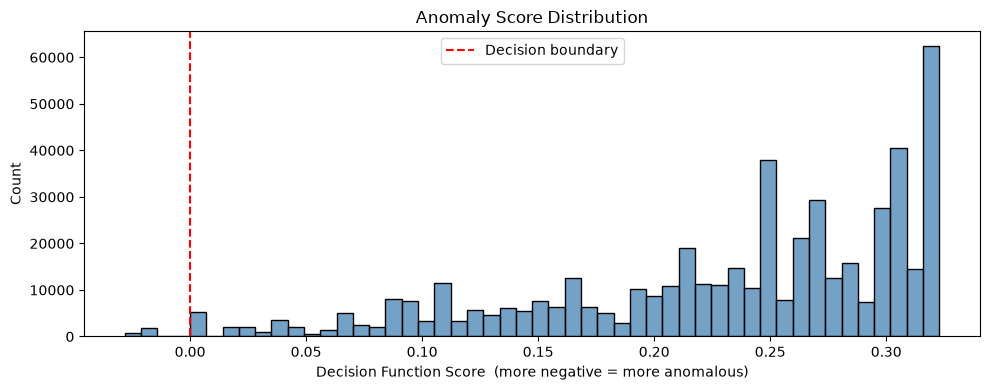

   ✓ Plot 1 done
   Plotting anomalies by hour...


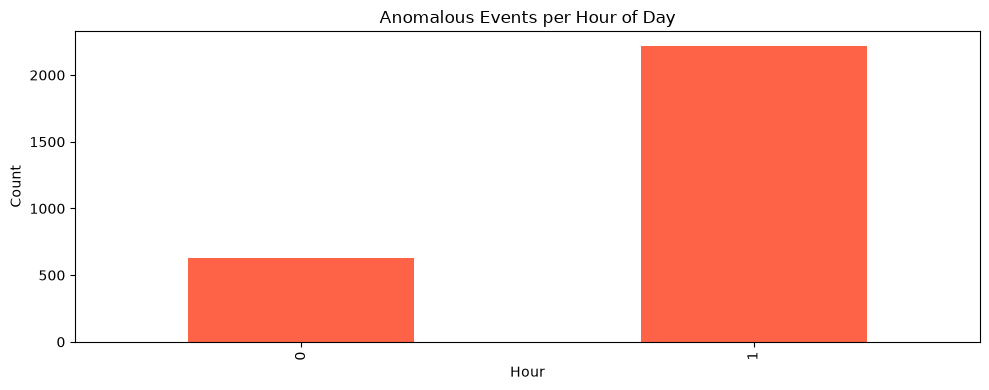

   ✓ Plot 2 done

✅ All plots rendered.


In [7]:
print("⏳ Generating plots...")

scores = model.decision_function(X_scaled)

# Plot 1: Anomaly score distribution
print("   Plotting anomaly score distribution...")
plt.figure(figsize=(10, 4))
sns.histplot(scores, bins=50, color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', label='Decision boundary')
plt.title('Anomaly Score Distribution')
plt.xlabel('Decision Function Score  (more negative = more anomalous)')
plt.legend()
plt.tight_layout()
plt.show()
print("   ✓ Plot 1 done")

# Plot 2: Anomalies by hour of day
print("   Plotting anomalies by hour...")
plt.figure(figsize=(10, 4))
df.groupby('hour')['anomaly'].apply(lambda x: (x == -1).sum()).plot(kind='bar', color='tomato')
plt.title('Anomalous Events per Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("   ✓ Plot 2 done")

print("\n✅ All plots rendered.")

In [8]:
print("⏳ Saving outputs...")

out_csv = DATA_PROCESSED / 'lanl_auth_with_anomalies.csv'
df.to_csv(out_csv, index=False)
print(f"   ✓ Dataset saved  → {out_csv}")

model_path = DATA_PROCESSED / 'isolation_forest_model.pkl'
scaler_path = DATA_PROCESSED / 'scaler.pkl'
joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)
print(f"   ✓ Model saved    → {model_path}")
print(f"   ✓ Scaler saved   → {scaler_path}")

print("\n✅ All outputs saved.")

⏳ Saving outputs...
   ✓ Dataset saved  → ..\data\processed\lanl_auth_with_anomalies.csv
   ✓ Model saved    → ..\data\processed\isolation_forest_model.pkl
   ✓ Scaler saved   → ..\data\processed\scaler.pkl

✅ All outputs saved.


In [9]:
print("=" * 45)
print("  NOTEBOOK 03 — SUMMARY")
print("=" * 45)
print(f"  Total auth events    : {len(df):,}")
print(f"  Anomalies detected   : {len(anomalies):,} ({len(anomalies)/len(df)*100:.2f}%)")
print(f"  Unique users         : {df['src_user'].nunique():,}")
print(f"  Unique source PCs    : {df['src_pc'].nunique():,}")
print(f"  Top anomalous user   : {top_anomalous_users.index[0] if len(top_anomalous_users) > 0 else 'N/A'}")
print("=" * 45)
print("✅ Notebook complete. Ready for next stage.")

  NOTEBOOK 03 — SUMMARY
  Total auth events    : 500,000
  Anomalies detected   : 2,846 (0.57%)
  Unique users         : 6,574
  Unique source PCs    : 4,062
  Top anomalous user   : ANONYMOUS LOGON@C586
✅ Notebook complete. Ready for next stage.
